# Base Notebook to re-create ovrlpy pipeline figures 

This notebook is the base notebook for 10X's Xenium brain showcase tissue sample. It runs the standard ovrlpy pipeline and saves the results to be used in further analysis.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from matplotlib_scalebar.scalebar import ScaleBar

import ovrlpy

In [2]:
centimeter = 1 / 2.54  # conversion from inch, for plotting

font = {"family": "sans-serif", "weight": "normal", "size": 8}

matplotlib.rc("font", **font)

data_folder_path = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

mapmycells_dir = Path(
    "/dh-projects/ag-ishaque/analysis/tiesmeys/data/ovrlpy/mapmycells/xenium-brain"
)

### Data loader:

In [3]:
import pickle

with open("../xenium_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts.to_pandas().set_index("transcript_id")
signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [4]:
signatures = pd.read_csv("../signatures.csv")

In [36]:
def anndata_from_mtx(path):
    import scipy as sp

    mtx = sp.io.mmread(path / "cell_feature_matrix/matrix.mtx").transpose().tocsr()
    obs = pd.read_parquet(path / "cells.parquet").set_index("cell_id", drop=False)
    obs.index.name += "_"
    var = pd.read_csv(
        path / "cell_feature_matrix/features.tsv",
        header=None,
        index_col=1,
        names=["gene_id", "gene", "feature_type"],
        sep="\t",
    )

    adata = ad.AnnData(mtx, obs=obs, var=var)
    adata = adata[:, adata.var["feature_type"] == "Gene Expression"]

    return adata.copy()


adata = anndata_from_mtx(data_folder_path)
adata

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy_dev/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 162033 × 248
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
    var: 'gene_id', 'feature_type'

In [6]:
from shapely.geometry import Polygon

cell_boundaries = pd.read_parquet(data_folder_path / "cell_boundaries.parquet")

nucleus_boundaries = pl.read_parquet(
    data_folder_path / "nucleus_boundaries.parquet"
).filter(pl.col("cell_id").is_in(adata.obs["cell_id"]))

boundaries = (
    nucleus_boundaries.lazy()
    .select("cell_id", pl.concat_arr(["vertex_x", "vertex_y"]).alias("coords"))
    .group_by("cell_id")
    .agg(pl.col("coords"))
    .collect()
)

polygons = [
    (Polygon(np.asarray(coords)), cell_id) for cell_id, coords in boundaries.iter_rows()
]

In [8]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

# ensure same dimensions as the ovrlpy map
origin = (
    ovrlpy.io.read_Xenium(data_folder_path / "transcripts.parquet")
    .select(("x", "y"))
    .min()
)
transform = from_origin(origin["x"][0], origin["y"][0], 1, -1)
segmentation_map = rasterize(
    polygons,
    out_shape=signal_integrity.shape,
    fill=-1,
    transform=transform,
    all_touched=True,
    dtype=int,
)

In [37]:
signal_integrity_integration_mask = (signal_strength > 1.5) & (segmentation_map > 0)

stats = (
    pd.DataFrame(
        {
            "signal_integrity": signal_integrity[signal_integrity_integration_mask],
            "segmentation_map": segmentation_map[signal_integrity_integration_mask],
        }
    )
    .groupby("segmentation_map")
    .agg(mean_integrity=("signal_integrity", "mean"))
)

adata.obs = pd.merge(adata.obs, stats, left_on="cell_id", right_index=True, how="left")

del stats

In [38]:
adata.obs["x_centroid"] -= origin["x"][0]
adata.obs["y_centroid"] -= origin["y"][0]

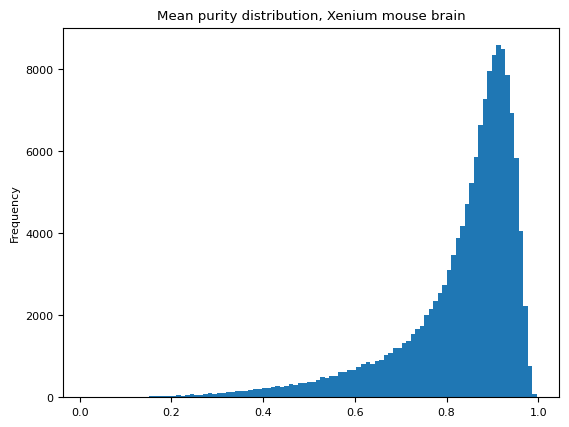

In [32]:
_ = adata.obs["mean_integrity"].plot.hist(
    bins=100, title="Mean purity distribution, Xenium mouse brain"
)

In [53]:
nuclear_df = coordinate_df.loc[lambda df: df["overlaps_nucleus"] == 1].copy()

nucleus_coordinates = (
    nuclear_df[["x", "y", "cell_id"]].groupby("cell_id").mean().add_prefix("nucleus_")
)
nucleus_coordinates.index = nucleus_coordinates.index.astype(str)

adata.obs = adata.obs.join(nucleus_coordinates, how="left")

adata.obs["nuclear_integrity"] = np.nan
adata.obs.loc[~adata.obs["nucleus_x"].isna(), "nuclear_integrity"] = signal_integrity[
    adata.obs["nucleus_y"].dropna().astype(int),
    adata.obs["nucleus_x"].dropna().astype(int),
]

#### Create count matrices for use in mapmycells:

In [61]:
def gene_counts(df):
    return (
        df.astype({"cell_id": str})
        .groupby(["gene", "cell_id"], observed=True)
        .size()
        .to_frame("n")
        .reset_index("gene")
        .pivot(columns="gene", values="n")
        .join(pd.DataFrame(index=adata.obs.index), how="right")
        .fillna(0)
        .astype(int)
    )


nuclear_df["z_delim"] = (
    nuclear_df[["cell_id", "z"]].groupby("cell_id").transform("median")
)


bottom_count_mtx = gene_counts(nuclear_df[nuclear_df["z"] < nuclear_df["z_delim"]])
top_count_mtx = gene_counts(nuclear_df[nuclear_df["z"] > nuclear_df["z_delim"]])

from scipy.sparse import csr_matrix

bottom = ad.AnnData(bottom_count_mtx)
bottom.X = csr_matrix(bottom.X)
bottom.write_h5ad("bottom_count_mtx_nuclei.h5ad")

top = ad.AnnData(top_count_mtx)
top.X = csr_matrix(top.X)
top.write_h5ad("top_count_mtx_nuclei.h5ad")

### Create a publishable HD figure of the colorized tissue:

Run mapmycells and proceed with results

In [65]:
# Correlation:
mapmycells_df_bottom = pd.read_csv("mapmycells/bottom.csv", index_col=0, comment="#")
mapmycells_df_bottom.index = mapmycells_df_bottom.index.astype(str)

mapmycells_df_top = pd.read_csv("mapmycells/top.csv", index_col=0, comment="#")
mapmycells_df_top.index = mapmycells_df_top.index.astype(str)

mapmycells_df_top["family_name"] = (
    mapmycells_df_top["class_name"].str.split(" ").str[-1].astype("category")
)
mapmycells_df_bottom["family_name"] = (
    mapmycells_df_bottom["class_name"].str.split(" ").str[-1].astype("category")
)

# ratio of coherently predicted cell types across the vertical demarcation:
global_prediction_coherence = (
    mapmycells_df_top["class_name"].astype(str)
    == mapmycells_df_bottom["class_name"].astype(str)
).mean()


all_classes = sorted(
    set(mapmycells_df_top["class_name"]) | set(mapmycells_df_bottom["class_name"])
)


celltype_combinations = pd.DataFrame(
    index=all_classes, columns=all_classes, dtype=float
)
counts = pd.Series(0, index=all_classes, dtype=int)


for i in celltype_combinations.index:
    for j in celltype_combinations.columns:
        celltype_combinations.loc[i, j] = (
            (mapmycells_df_top["class_name"] == i)
            & (mapmycells_df_bottom["class_name"] == j)
        ).sum()

    counts[i] = (
        (mapmycells_df_top["class_name"] == i)
        | (mapmycells_df_bottom["class_name"] == i)
    ).sum()

celltype_combinations = celltype_combinations + celltype_combinations.T
celltype_combinations /= np.eye(len(celltype_combinations)) + 1

celltype_combinations /= celltype_combinations.sum(1)
celltype_combinations = celltype_combinations.T

celltype_combinations.index = (
    celltype_combinations.index.str.split(" ").str[1:].str.join(" ")
)
celltype_combinations.columns = (
    celltype_combinations.columns.str.split(" ").str[1:].str.join(" ")
)

annotations = pd.DataFrame("", index=all_classes, columns=all_classes, dtype=str)
for i in range(len(celltype_combinations)):
    annotations.iloc[i, i] = f"{celltype_combinations.iloc[i,i]:.1f}"

print(f"{global_prediction_coherence:.2f} coherent")

0.81 coherent


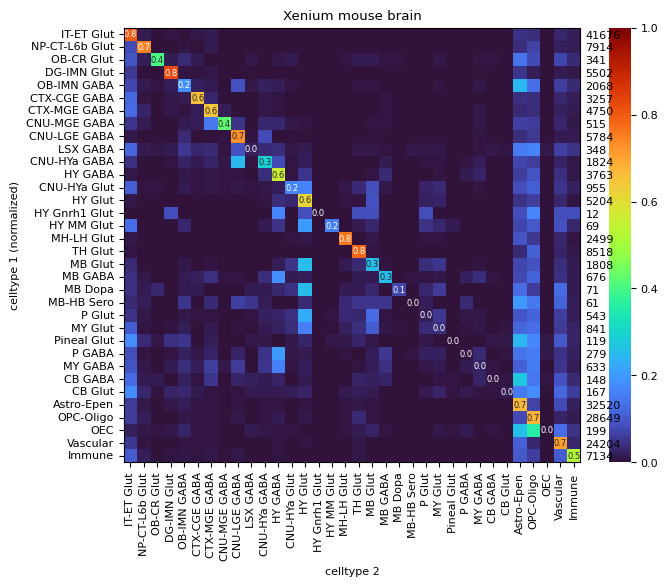

In [66]:
fig, ax = plt.subplots(figsize=(18 * centimeter, 15 * centimeter))

sns.heatmap(
    celltype_combinations,
    annot=annotations,
    ax=ax,
    cmap="turbo",
    fmt="",
    vmin=0,
    vmax=1,
    annot_kws={"size": 6},
)


# Set the secondary y-axis ticks and labels
ax2 = ax.twinx()
ax2.set_yticks(ax.get_yticks(), labels=counts.astype(str))
ax2.tick_params(axis="y", length=0)
ax2.set_ylim(ax.get_ylim())
ax.set(
    xlabel="celltype 2", ylabel="celltype 1 (normalized)", title="Xenium mouse brain"
)
fig.tight_layout()

fig.savefig("celltype_combinations.pdf", dpi=300)
fig.savefig("celltype_combinations.svg", dpi=300)

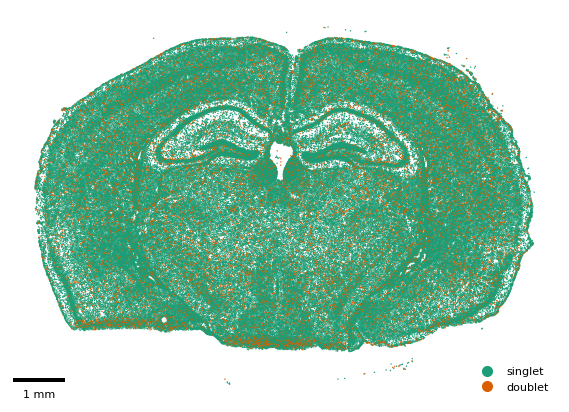

In [70]:
fig, ax = plt.subplots(figsize=(18 * centimeter, 15 * centimeter))

adata.obs["cell"] = pd.Series(
    np.where(
        mapmycells_df_top["family_name"] == mapmycells_df_bottom["family_name"],
        "singlet",
        "doublet",
    ),
    index=mapmycells_df_top.index,
)


sns.scatterplot(
    data=adata.obs,
    x="x_centroid",
    y="y_centroid",
    hue="cell",
    s=1,
    ax=ax,
    lw=0,
    palette="Dark2",
)

plt.legend(
    *ax.get_legend_handles_labels(),
    loc="lower right",
    title=None,
    frameon=False,
    markerscale=8
)

ax.add_artist(ScaleBar(1, units="um", length_fraction=0.1, loc="lower left"))
ax.set_axis_off()
ax.set_aspect("equal", adjustable="box")


fig.savefig("doublet_map.pdf", dpi=600)
fig.savefig("doublet_map.svg", dpi=600)

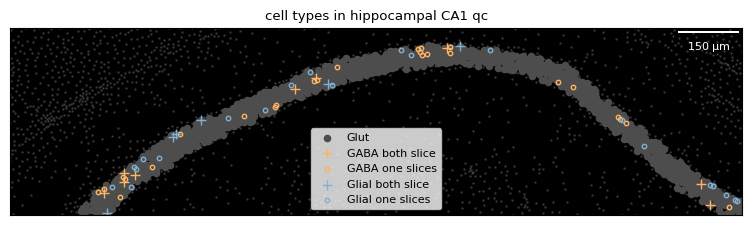

In [78]:
import matplotlib
from scipy.ndimage import gaussian_filter

glial_classes = ["30 Astro-Epen", "33 Vascular", "31 OPC-Oligo", "34 Immune"]

class_color_dict = {
    "Dopa": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "Glut": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "Inh": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "Astro-Epen": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "Vascular": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "OPC-Oligo": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Immune": (1.0, 1.0, 0.7019607843137254),
    "OEC": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
}

c_glial = class_color_dict["OPC-Oligo"]
c_Inh = class_color_dict["Inh"]

fig, ax = plt.subplots(figsize=(24 * centimeter, 12 * centimeter))

kwargs = dict(x="x_centroid", y="y_centroid", ax=ax)


# xlim_ca1 = (1400 * 2, 3600 * 2)
xlim_ca1 = (1400 * 2, 2300 * 2)
# ylim_ca1 = (2510 * 2, 2730 * 2)
ylim_ca1 = (2500 * 2, 2730 * 2)


dense_map = (
    gaussian_filter((gaussian_filter(signal_strength, 10) > 3).astype(float), 13) > 0.3
)
is_dense = dense_map[
    adata.obs["y_centroid"].astype(int), adata.obs["x_centroid"].astype(int)
]
in_view = adata.obs["x_centroid"].between(*xlim_ca1) & adata.obs["y_centroid"].between(
    *ylim_ca1
)
is_ca1 = is_dense & in_view

ca1_df = adata.obs[is_ca1]
class_top = mapmycells_df_top.loc[is_ca1, "class_name"]
class_bottom = mapmycells_df_bottom.loc[is_ca1, "class_name"]

adata.obs[in_view].plot.scatter(c="darkgrey", s=1, alpha=0.2, **kwargs)
adata.obs[is_ca1].plot.scatter(
    color=(0.3, 0.3, 0.3), s=20, alpha=1.0, label="Glut", rasterized=True, **kwargs
)

ca1_df[class_top.str.contains("GABA") & class_bottom.str.contains("GABA")].plot.scatter(
    marker="+", color=c_Inh, linewidth=1, s=50, label="GABA both slice", **kwargs
)

ca1_df[class_top.str.contains("GABA") ^ class_bottom.str.contains("GABA")].plot.scatter(
    color=(0, 0, 0, 0),
    edgecolors=c_Inh,
    linewidth=1,
    s=10,
    label="GABA one slices",
    **kwargs
)

ca1_df[class_top.isin(glial_classes) & class_bottom.isin(glial_classes)].plot.scatter(
    marker="+", color=c_glial, linewidth=1, s=50, label="Glial both slice", **kwargs
)

ca1_df[class_top.isin(glial_classes) ^ class_bottom.isin(glial_classes)].plot.scatter(
    color=(0, 0, 0, 0),
    edgecolors=c_glial,
    linewidth=1,
    s=10,
    label="Glial one slices",
    **kwargs
)

plt.legend(loc="lower center")

ax.set(
    facecolor="k",
    xlim=xlim_ca1,
    ylim=ylim_ca1,
    aspect="equal",
    title="cell types in hippocampal CA1 qc",
    xlabel="",
    ylabel="",
    yticks=[],
    xticks=[],
)

ax.add_artist(ScaleBar(1, units="um", frameon=False, color="w", length_fraction=0.1))

fig.savefig("ca1_cell_scatter.pdf", dpi=600)
fig.savefig("ca1_cell_scatter.svg", dpi=600)

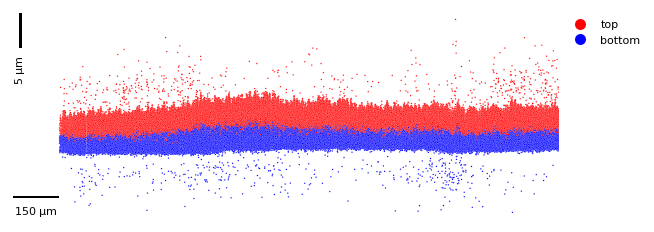

In [79]:
fig, ax = plt.subplots(figsize=(18 * centimeter, 7 * centimeter))

is_dense_molecule = dense_map[
    coordinate_df["y"].astype(int), coordinate_df["x"].astype(int)
]
is_ca1_molecule = (
    is_dense_molecule
    & coordinate_df["x"].between(*xlim_ca1)
    & coordinate_df["y"].between(*ylim_ca1)
)

ca1_coordinates = coordinate_df[is_ca1_molecule].assign(
    virtual_slice=lambda df: pd.Categorical(
        np.where(df["z"] > df["z_center"], "top", "bottom"),
        categories=["top", "bottom"],
    )
)


sns.scatterplot(
    data=ca1_coordinates,
    x="x",
    y="z",
    hue="virtual_slice",
    s=1,
    palette={"top": "r", "bottom": "b"},
)

ax.set_xlim(*xlim_ca1)

ax.add_artist(
    ScaleBar(
        1,
        units="um",
        frameon=False,
        length_fraction=0.1,
        rotation="horizontal-only",
        loc="lower left",
    )
)
ax.add_artist(
    ScaleBar(
        1,
        units="um",
        frameon=False,
        length_fraction=0.2,
        width_fraction=0.005,
        rotation="vertical-only",
        loc="upper left",
    )
)
plt.legend(
    *ax.get_legend_handles_labels(),
    markerscale=8,
    # loc="lower right",
    title=None,
    frameon=False,
    bbox_to_anchor=(1, 1)
)
ax.set_axis_off()

fig.savefig("ca1_top_bottom_scatter.pdf", dpi=600)
fig.savefig("ca1_top_bottom_scatter.svg", dpi=600)

In [80]:
ca1_df_top = mapmycells_df_top[is_ca1].copy()
ca1_df_bottom = mapmycells_df_bottom[is_ca1].copy()

all_classes = sorted(set(ca1_df_top["family_name"]) | set(ca1_df_bottom["family_name"]))


global_prediction_coherence = (
    ca1_df_top.family_name.astype(str) == ca1_df_bottom.family_name.astype(str)
)[~((ca1_df_top.family_name == "Glut") & (ca1_df_bottom.family_name == "Glut"))].mean()

celltype_combinations = pd.DataFrame(
    index=all_classes, columns=all_classes, dtype=float
)
counts = pd.Series(0, index=all_classes, dtype=int)


for i in celltype_combinations.index:
    for j in celltype_combinations.columns:
        celltype_combinations.loc[i, j] = (
            (ca1_df_top["family_name"] == i) & (ca1_df_bottom["family_name"] == j)
        ).sum()

    counts[i] = (
        (ca1_df_top["family_name"] == i) | (ca1_df_bottom["family_name"] == i)
    ).sum()

celltype_combinations = celltype_combinations + celltype_combinations.T
celltype_combinations /= np.eye(len(celltype_combinations)) + 1

celltype_combinations[:] = celltype_combinations / celltype_combinations.sum(1)
celltype_combinations = celltype_combinations.T


axis_ticks = ["Astro-Epen", "Immune", "OPC-Oligo", "Vascular", "GABA", "Glut"]

annotations = pd.DataFrame("", index=all_classes, columns=all_classes, dtype=str)
for i in range(len(celltype_combinations.index)):
    annotations.iloc[i, i] = f"{celltype_combinations.iloc[i,i]:.2f}"

0.24 non-glut coherent


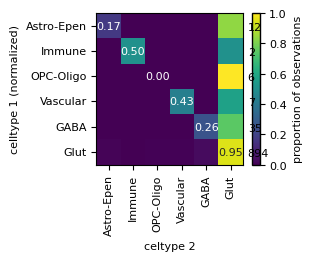

In [81]:
fig, ax = plt.subplots(figsize=(6 * centimeter, 5 * centimeter))
sns.heatmap(
    celltype_combinations.loc[axis_ticks, axis_ticks],
    annot=annotations.loc[axis_ticks, axis_ticks],
    ax=ax,
    cmap="viridis",
    fmt="",
    cbar_kws={"label": "proportion of observations"},
)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
ax.set(ylabel="celltype 1 (normalized)", xlabel="celtype 2")
# ax.set_title(f"Xenium hippocampal combinations, normalized")

# Set the secondary y-axis ticks and labels
ax2 = ax.twinx()
ax2.set_yticks(ax.get_yticks(), labels=counts[axis_ticks].astype(str))
ax2.tick_params(length=0)
ax2.set_ylim(ax.get_ylim())

# fig.tight_layout()

for spine in fig.axes[1].spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1)

fig.savefig("ca1_inh_combinations.pdf", dpi=300)
fig.savefig("ca1_inh_combinations.svg", dpi=300)

print(f"{global_prediction_coherence:.2f} non-glut coherent")

#### A quantification of ovrlpy, using the signal integrity map:

In [83]:
# perform statistics between coherent and incoherent samples:
from scipy.stats import normaltest, ttest_ind

print("Mean integrity values:")

gaba_coherent_integrity_samples = ca1_df.loc[
    class_top.str.contains("GABA") & class_bottom.str.contains("GABA"),
    "nuclear_integrity",
]
gaba_incoherent_integrity_samples = ca1_df.loc[
    class_top.str.contains("GABA") ^ class_bottom.str.contains("GABA"),
    "nuclear_integrity",
]

# Test for normality:
print(f"GABA coherent normality: {normaltest(gaba_coherent_integrity_samples)}")
print(f"GABA incoherent normality: {normaltest(gaba_incoherent_integrity_samples)}")
ttest_gaba = ttest_ind(
    gaba_coherent_integrity_samples, gaba_incoherent_integrity_samples, equal_var=False
)

print(f"GABA coherent: {gaba_coherent_integrity_samples.mean()}")
print(f"GABA incoherent: {gaba_incoherent_integrity_samples.mean()}")
print(f"GABA t-test: {ttest_gaba}")
print()

glial_coherent_integrity_samples = ca1_df[
    class_top.isin(glial_classes) & class_bottom.isin(glial_classes)
]
glial_incoherent_integrity_samples = ca1_df[
    class_top.isin(glial_classes) ^ class_bottom.isin(glial_classes)
]

# Test for normality:
print(
    f"Glial coherent normality: {normaltest(glial_coherent_integrity_samples['nuclear_integrity'])}"
)
print(
    f"Glial incoherent normality: {normaltest(glial_incoherent_integrity_samples['nuclear_integrity'])}"
)
ttest_glial = ttest_ind(
    glial_coherent_integrity_samples["nuclear_integrity"],
    glial_incoherent_integrity_samples["nuclear_integrity"],
    equal_var=False,
)

print(f"Glial coherent: {glial_coherent_integrity_samples['nuclear_integrity'].mean()}")
print(
    f"Glial incoherent: {glial_incoherent_integrity_samples['nuclear_integrity'].mean()}"
)
print(f"Glial t-test: {ttest_glial}")

Mean integrity values:
GABA coherent normality: NormaltestResult(statistic=np.float64(14.996572766399954), pvalue=np.float64(0.0005540329573416993))
GABA incoherent normality: NormaltestResult(statistic=np.float64(0.067090026586318), pvalue=np.float64(0.9670113818848898))
GABA coherent: 0.9053780370288425
GABA incoherent: 0.6625018899257367
GABA t-test: TtestResult(statistic=np.float64(5.945910593308729), pvalue=np.float64(1.5481382539526889e-06), df=np.float64(30.368020549042605))

Glial coherent normality: NormaltestResult(statistic=np.float64(nan), pvalue=np.float64(nan))
Glial incoherent normality: NormaltestResult(statistic=np.float64(2.139767385445027), pvalue=np.float64(0.34304841412561604))
Glial coherent: 0.8960752884546915
Glial incoherent: 0.8109765336627052
Glial t-test: TtestResult(statistic=np.float64(4.162840427534163), pvalue=np.float64(0.00033027588402491457), df=np.float64(24.795821286318564))


/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy_dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)
/tmp/ipykernel_3451347/924254606.py:36: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f"Glial coherent normality: {normaltest(glial_coherent_integrity_samples['nuclear_integrity'])}"


In [84]:
from scipy.stats import mannwhitneyu

mwu_gaba = mannwhitneyu(
    gaba_coherent_integrity_samples, gaba_incoherent_integrity_samples, method="auto"
)
mwu_glial = mannwhitneyu(
    glial_coherent_integrity_samples["nuclear_integrity"],
    glial_incoherent_integrity_samples["nuclear_integrity"],
    method="auto",
)

print(f"GABA MWU: {mwu_gaba}")
print(f"Glial MWU: {mwu_glial}")

GABA MWU: MannwhitneyuResult(statistic=np.float64(213.0), pvalue=np.float64(0.00031285654397390084))
Glial MWU: MannwhitneyuResult(statistic=np.float64(103.0), pvalue=np.float64(0.01814803553933989))


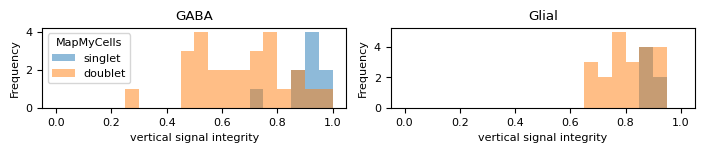

In [85]:
# font = {"family": "Nimbus Sans", "weight": "normal", "size": 8}

# matplotlib.rc("font", **font)


fig = plt.figure(figsize=(18 * centimeter, 4 * centimeter))

plt.subplot(121)

gaba_coherent_integrity_samples.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="singlet"
)
gaba_incoherent_integrity_samples.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="doublet"
)

plt.ylabel("Frequency")
plt.xlabel("vertical signal integrity")
plt.legend(title="MapMyCells")
plt.title("GABA")


plt.subplot(122)

glial_coherent_integrity_samples.nuclear_integrity.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="singlet"
)
glial_incoherent_integrity_samples.nuclear_integrity.plot.hist(
    bins=20, range=(0, 1), alpha=0.5, label="doublet"
)

plt.ylabel("Frequency")
plt.xlabel("vertical signal integrity")
plt.title("Glial")

plt.tight_layout()

plt.savefig("ca1_integrity_histograms.svg", dpi=600)

#### Print cell segments from top-bottom-missmatches with outlines:

In [24]:
from matplotlib.cm import Set3

cell_boundaries = pd.read_parquet(data_folder_path / "cell_boundaries.parquet")
nucleus_boundaries = pd.read_parquet(data_folder_path / "nucleus_boundaries.parquet")

In [25]:
gene_group_df = pd.read_csv(
    data_folder_path / "Xenium_V1_FF_Mouse_Brain_MultiSection_Input_gene_groups.csv",
    header=0,
    index_col=0,
    usecols=[0, 1],
)
gene_group_df["idx"] = range(len(gene_group_df))

In [26]:
{c: color for c, color in zip(mapmycells_df_top.family_name.unique(), Set3.colors)}

class_color_dict = {
    "Dopa": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "Glut": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "Inh": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "Astro-Epen": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "Vascular": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "OPC-Oligo": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Immune": (1.0, 1.0, 0.7019607843137254),
    "OEC": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
}

marker_color_dict = {
    "Neurons": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "Endothelial": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "Astrocytes": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "Oligodendrocytes": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "Microglia": (1.0, 1.0, 0.7019607843137254),
}

In [27]:
from shapely.geometry import Polygon as Polygon

mismatch_ids = mapmycells_df_top[
    (mapmycells_df_top.family_name != mapmycells_df_bottom.family_name)
].index


def plot_cells_in_window(x, y, window_size, plot_markers=True):
    in_window_cell_boundaries = cell_boundaries[
        (cell_boundaries.vertex_x.between(x - window_size, x + window_size))
        & (cell_boundaries.vertex_y.between(y - window_size, y + window_size))
    ]
    in_window_nucleus_boundaries = nucleus_boundaries[
        (nucleus_boundaries.vertex_x.between(x - window_size, x + window_size))
        & (nucleus_boundaries.vertex_y.between(y - window_size, y + window_size))
    ]

    in_window_ids = in_window_cell_boundaries.cell_id.unique()

    in_window_top_df = mapmycells_df_top.loc[in_window_ids]
    in_window_bottom_df = mapmycells_df_bottom.loc[in_window_ids]

    polygons_cell = {}
    polygons_nucleus = {}

    for i, cell_id in enumerate(in_window_ids):
        subset_cell_boundaries = cell_boundaries[cell_boundaries.cell_id == cell_id]
        subset_nucleus_boundaries = nucleus_boundaries[
            nucleus_boundaries.cell_id == cell_id
        ]

        polygons_cell[cell_id] = Polygon(
            subset_cell_boundaries[["vertex_x", "vertex_y"]].values
        )
        polygons_nucleus[cell_id] = Polygon(
            subset_nucleus_boundaries[["vertex_x", "vertex_y"]].values
        )

    fig1, ax = plt.subplots(1, 2, figsize=(12, 6))

    for i, cell_id in enumerate(in_window_ids):
        color = Set3.colors[i % len(Set3.colors)]
        # if polygons_cell[cell_id] is None:
        #     continue
        x_verteces, y_verteces = polygons_cell[cell_id].exterior.xy
        ax[0].plot(x_verteces, y_verteces, "-", color="white", linewidth=1, alpha=0.8)
        ax[1].plot(x_verteces, y_verteces, "-", color="white", linewidth=1, alpha=0.8)

        # if polygons_nucleus[cell_id] is None:
        #     continue
        x_verteces, y_verteces = polygons_nucleus[cell_id].exterior.xy
        ax[0].fill(
            x_verteces,
            y_verteces,
            color=class_color_dict[in_window_top_df.loc[cell_id].family_name],
            alpha=1,
            linewidth=3,
        )
        ax[1].fill(
            x_verteces,
            y_verteces,
            color=class_color_dict[in_window_bottom_df.loc[cell_id].family_name],
            alpha=1,
            linewidth=3,
        )

    plt.legend(
        [
            plt.scatter([], [], color=color, label=class_name)
            for class_name, color in class_color_dict.items()
        ],
        class_color_dict.keys(),
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
    )

    for a in ax:
        a.set(xticks=[], yticks=[], aspect="equal", facecolor="black")
        a.set_ylim(int(y - window_size), int(y + window_size) + 1)
        a.set_xlim(int(x - window_size), int(x + window_size) + 1)

    if not plot_markers:
        return fig1

    subset_df = coordinate_df[
        (coordinate_df.x.between(x - window_size, x + window_size))
        & (coordinate_df.y.between(y - window_size, y + window_size))
    ]

    fig2, ax = plt.subplots(1, 2, figsize=(12, 6))

    subset_df.plot.scatter("x", "y", c="k", s=0.1, ax=ax[0], rasterized=True)
    subset_df.plot.scatter("x", "y", c="k", s=0.1, ax=ax[1], rasterized=True)

    for i, marker_type in enumerate(marker_color_dict.keys()):
        subset_marker_df = subset_df[
            subset_df.gene.isin(gene_group_df[gene_group_df.group == marker_type].index)
        ]
        subset_marker_df[subset_marker_df.z > subset_marker_df.z_center].plot.scatter(
            "x",
            "y",
            color=marker_color_dict[marker_type],
            s=2,
            ax=ax[0],
            rasterized=True,
        )
        subset_marker_df[subset_marker_df.z < subset_marker_df.z_center].plot.scatter(
            "x",
            "y",
            color=marker_color_dict[marker_type],
            s=2,
            ax=ax[1],
            rasterized=True,
        )

    for i, cell_id in enumerate(in_window_ids):
        color = Set3.colors[i % len(Set3.colors)]
        # if polygons_cell[cell_id] is None:
        #     continue
        x_verteces, y_verteces = polygons_cell[cell_id].exterior.xy
        ax[0].plot(x_verteces, y_verteces, "-", color="white", linewidth=1, alpha=0.8)
        ax[1].plot(x_verteces, y_verteces, "-", color="white", linewidth=1, alpha=0.8)

    for a in ax:
        a.set(xticks=[], yticks=[], aspect="equal", facecolor="black")
        a.set_ylim(int(y - window_size), int(y + window_size) + 1)
        a.set_xlim(int(x - window_size), int(x + window_size) + 1)
        a.set(xlabel=None, ylabel=None)

    plt.legend(
        [
            plt.scatter([], [], color=color, label=marker_name)
            for marker_name, color in marker_color_dict.items()
        ],
        marker_color_dict.keys(),
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
    )
    fig1.tight_layout()
    fig2.tight_layout()

    return fig1, fig2

In [28]:
inh_classes = {x: "Inh" for x in ["GABA", "Sero"]}

classes = {
    x: x for x in mapmycells_df_bottom["family_name"].cat.categories
} | inh_classes

mapmycells_df_bottom["family_name"] = (
    mapmycells_df_bottom["family_name"].map(classes).astype("category")
)
mapmycells_df_top["family_name"] = (
    mapmycells_df_top["family_name"].map(classes).astype("category")
)

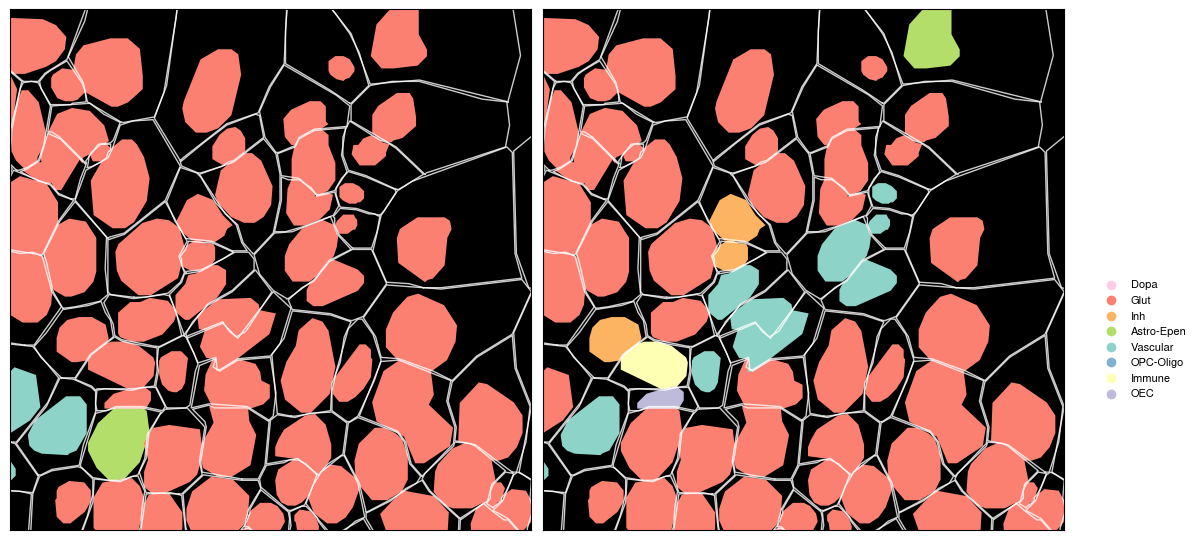

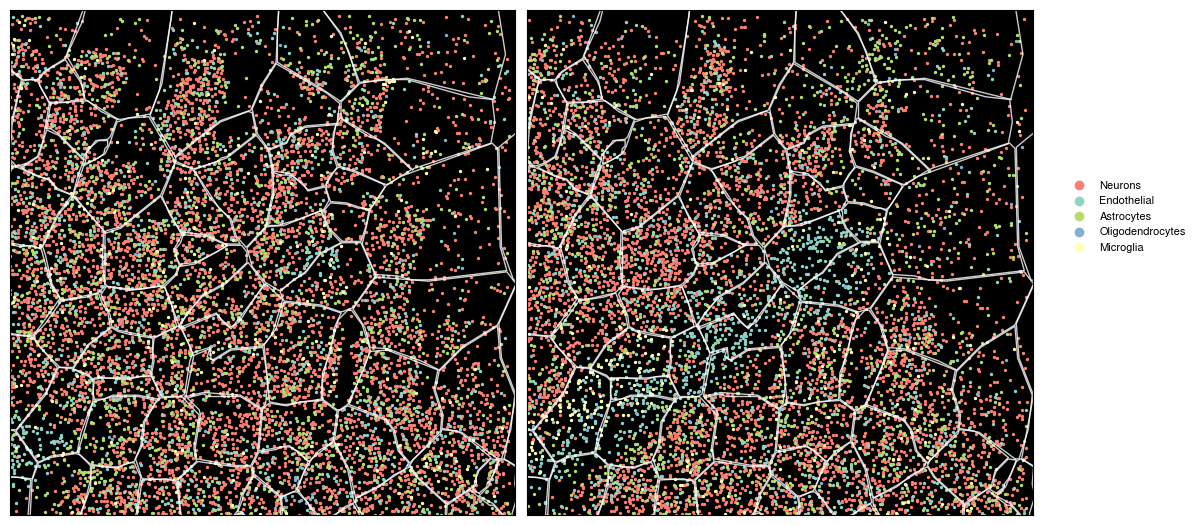

In [29]:
x, y = 6900, 5080

window_size = 40

fig1, fig2 = plot_cells_in_window(x, y, window_size)

fig1.savefig("ca1_MMC_outlines.svg", dpi=300)
fig2.savefig("ca1_MMC_markers.svg", dpi=600)

In [30]:
doublet_df = brain.detect_doublets(min_signal=3, integrity_sigma=2)

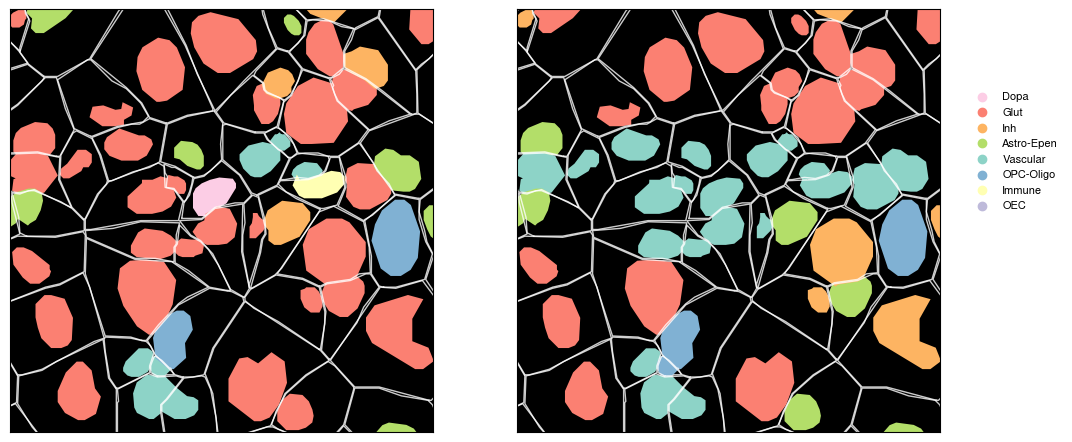

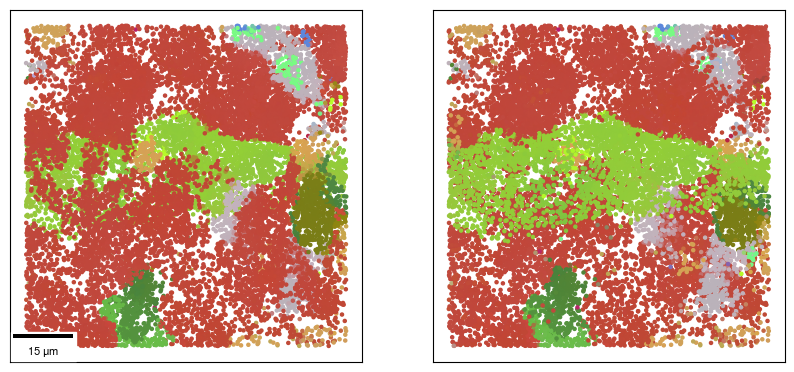

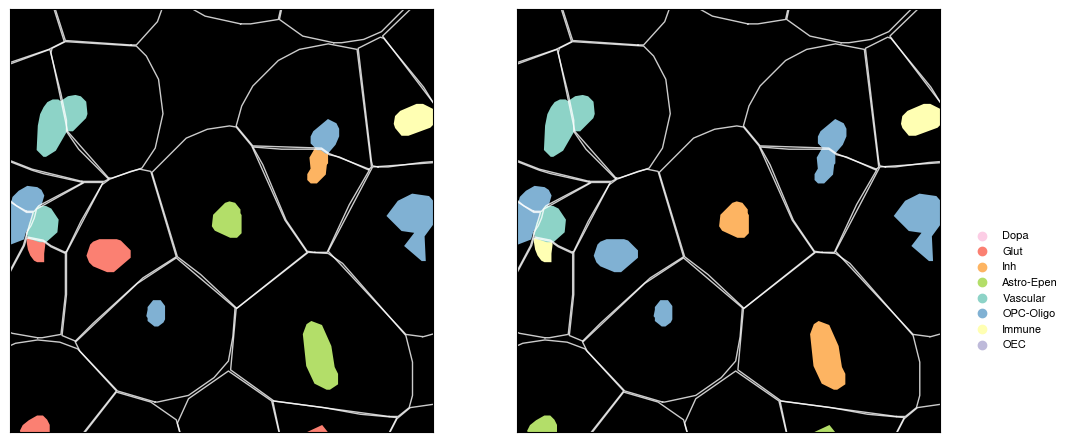

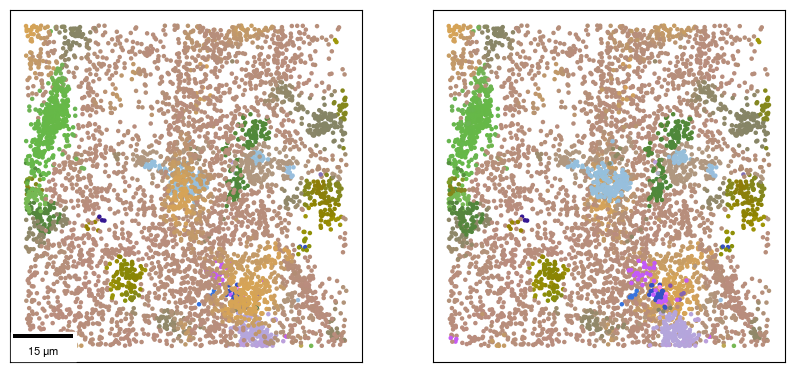

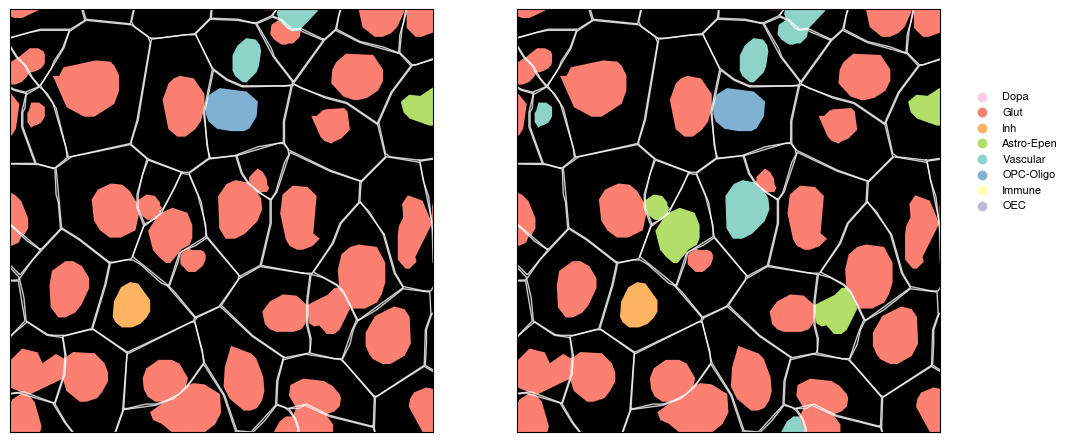

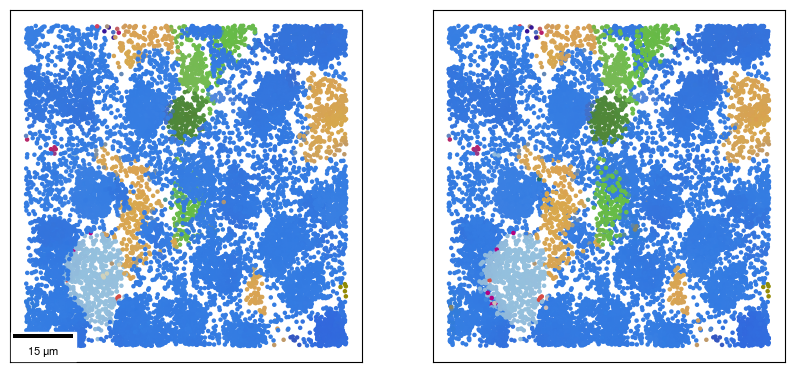

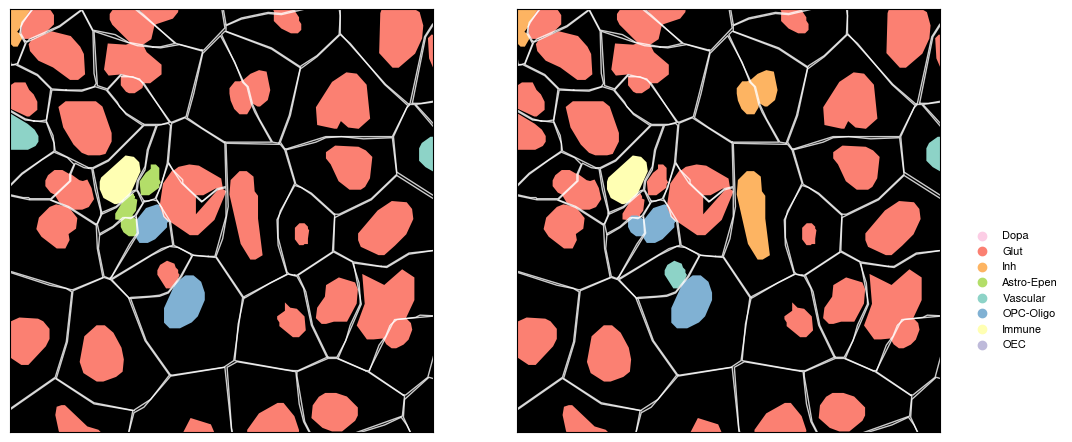

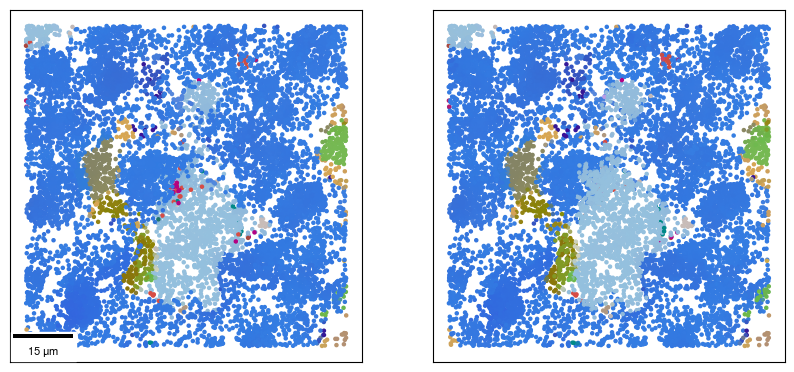

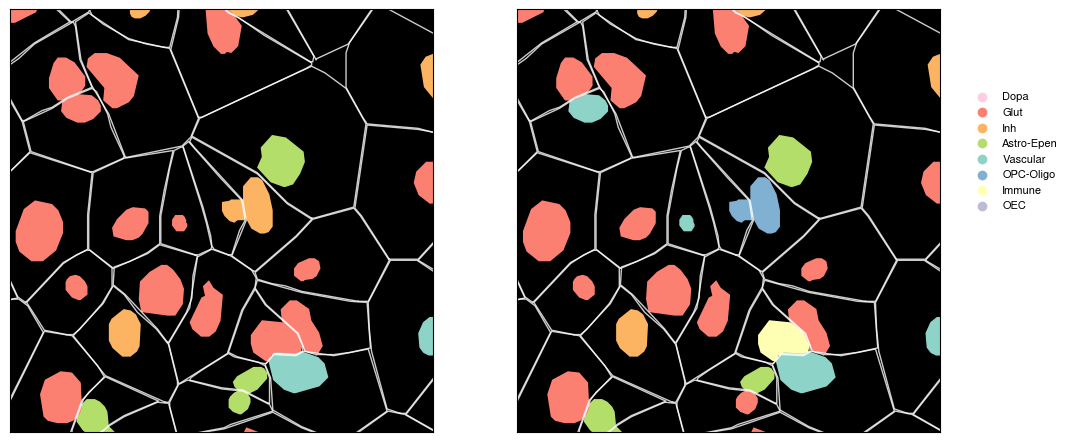

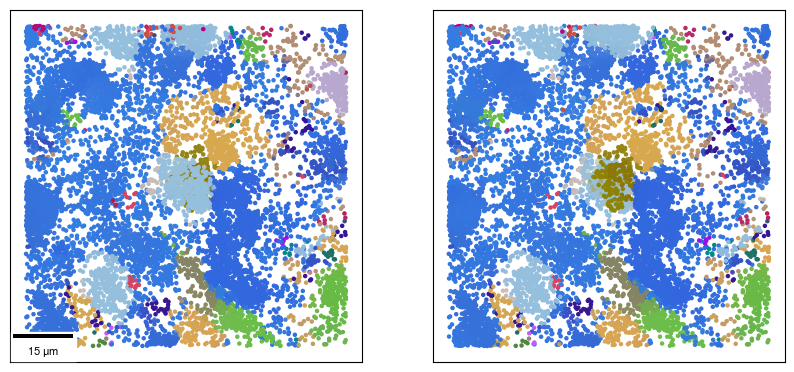

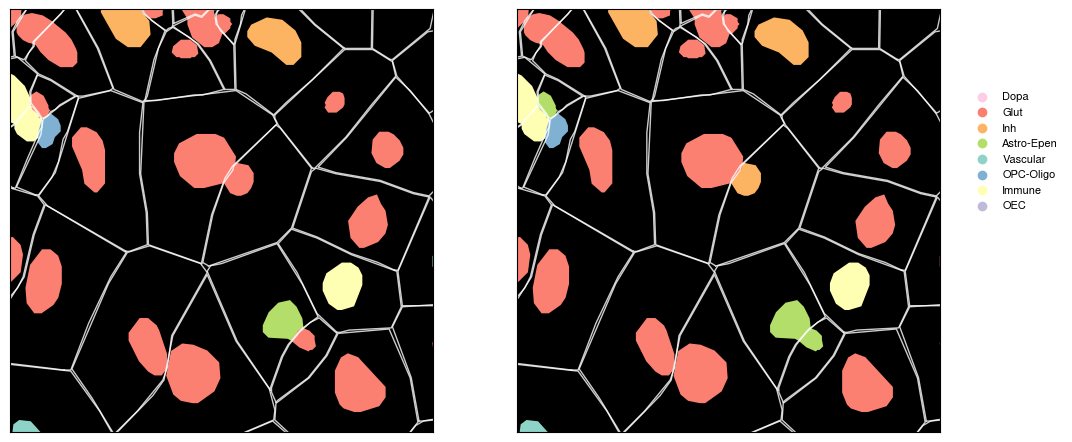

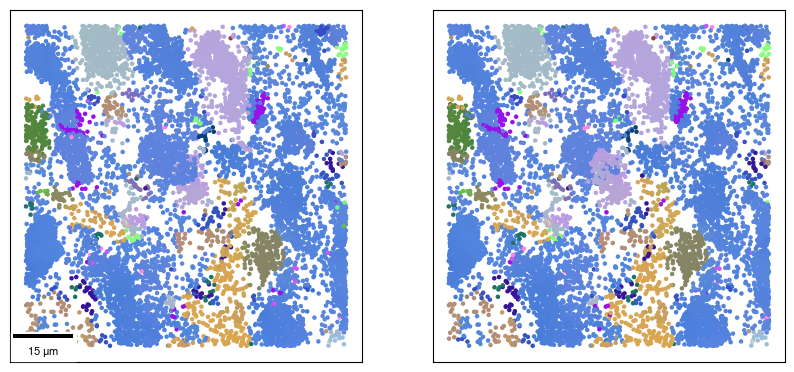

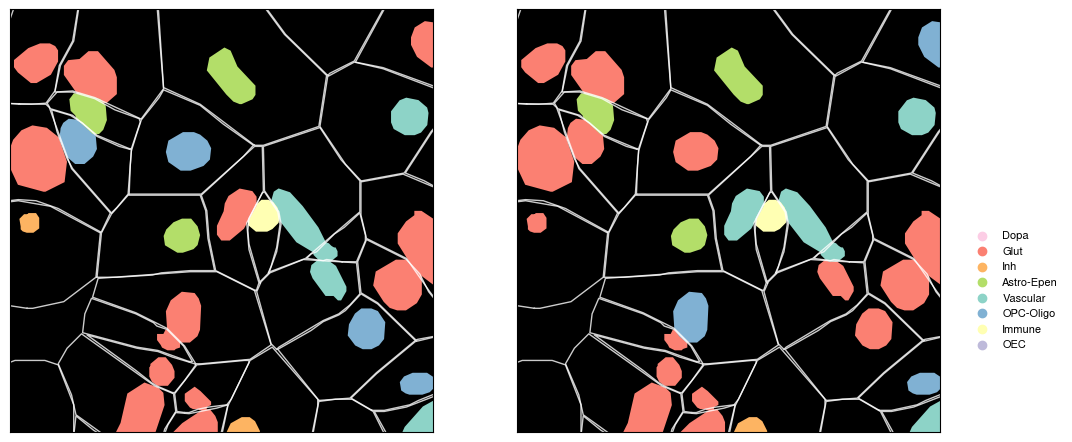

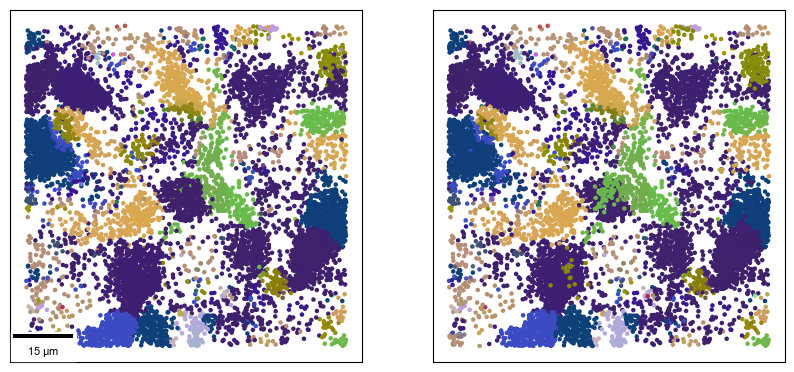

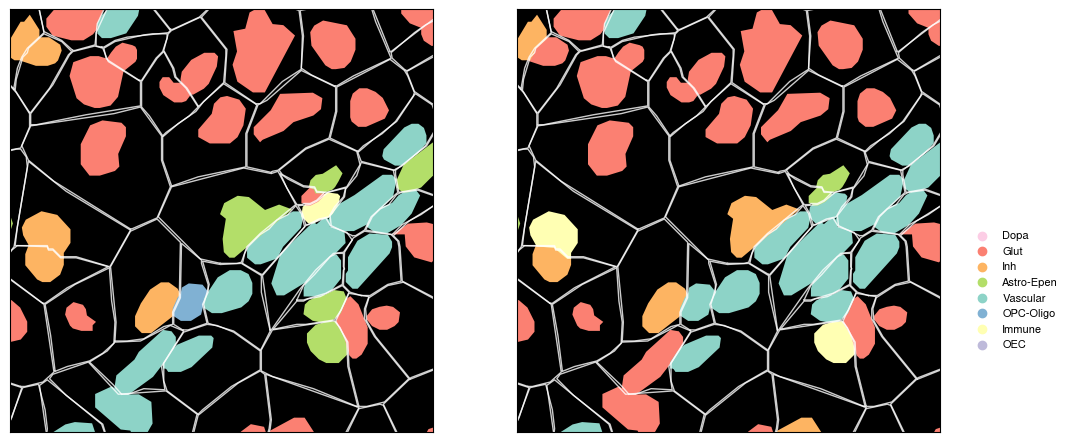

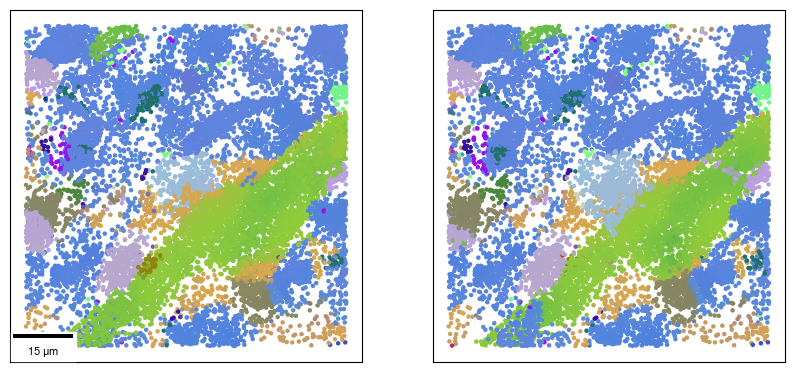

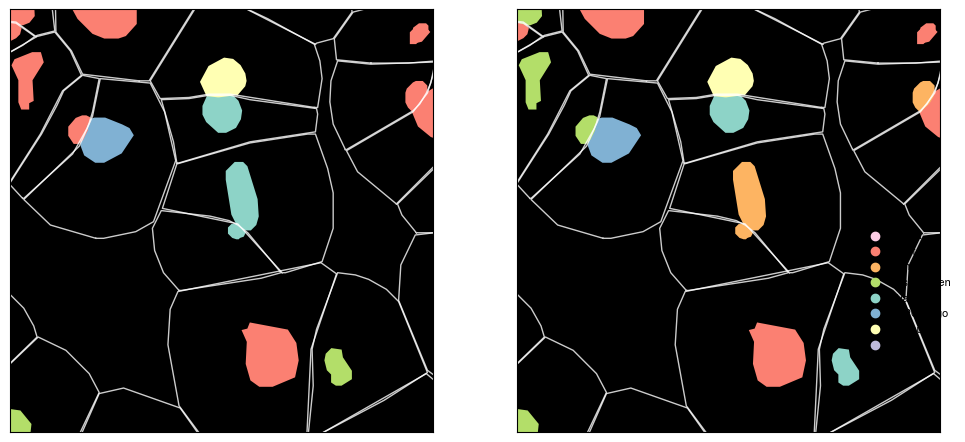

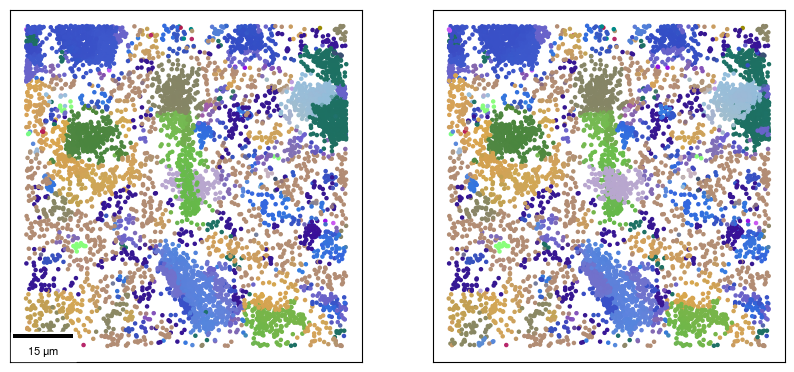

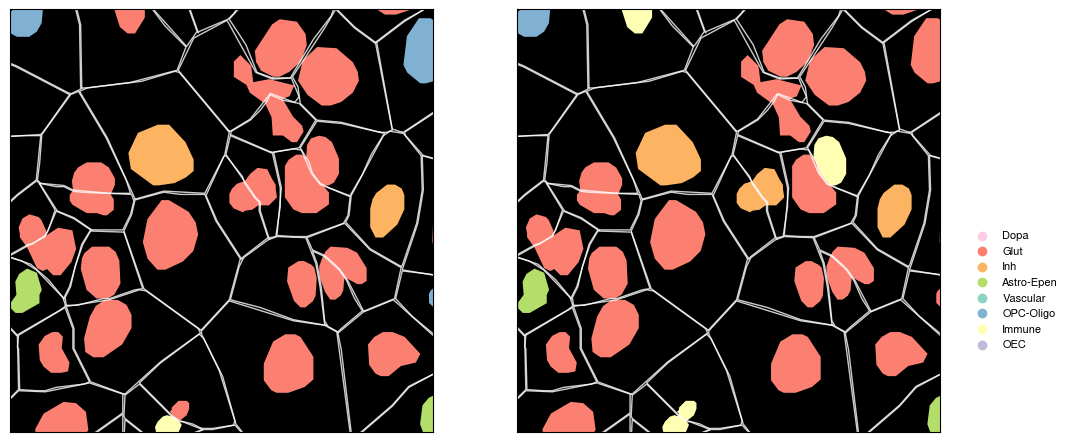

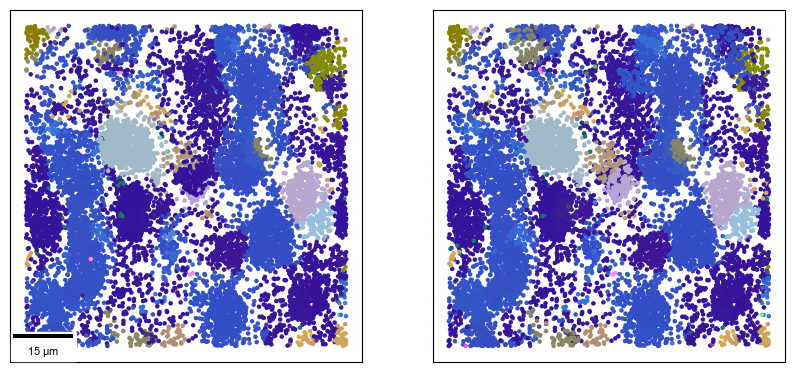

In [31]:
n_cases = 10

for i in range(n_cases):
    x, y = doublet_df[["x", "y"]].row(i)

    fig = plot_cells_in_window(x, y, window_size, plot_markers=False)
    fig.savefig(f"MMC-ovrlpy-overlaps-{i}.svg", dpi=600)
    subsample = brain.subset_transcripts(x, y, window_size=window_size).sort("z")
    _, embedding_color = brain.transform_transcripts(subsample)
    subsample = subsample.with_columns(RGB=embedding_color)

    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

    axs[0].scatter(
        x=subsample["x"],
        y=subsample["y"],
        color=subsample["RGB"],
        s=5,
        # rasterized=True,
    )
    # plt.scatter(x, y, c="k", marker="x", s=20)
    axs[0].set(aspect="equal", xticks=[], yticks=[])
    axs[0].add_artist(ScaleBar(1, units="um", length_fraction=0.2, loc="lower left"))

    axs[1].scatter(
        x=subsample["x"].reverse(),
        y=subsample["y"].reverse(),
        color=subsample["RGB"].reverse(),
        s=5,
        # rasterized=True,
    )
    axs[1].set(aspect="equal", xticks=[], yticks=[])

    fig.savefig(f"MMC-ovrlpy-overlaps-{i}-ovrlpy.svg", dpi=600)

### Visualizing doublet embedding behavior in UMAP space: 

In [86]:
from sklearn.decomposition import PCA
from umap import UMAP

from ovrlpy._plotting import BIH_CMAP

random_state = 42


umap = UMAP(n_components=2, n_neighbors=20, random_state=random_state)
pca = PCA(n_components=30, random_state=random_state)

pca_global = pca.fit_transform(adata.X.toarray())
embedding_global = umap.fit_transform(pca_global)

pca_cleaned = pca.fit_transform(adata[adata.obs["mean_integrity"] > 0.7, :].X.toarray())
embedding_cleaned = umap.fit_transform(pca_cleaned)

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy_dev/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [94]:
plot_df = pd.DataFrame(
    {"x": embedding_global[:, 0], "y": embedding_global[:, 1]}, index=adata.obs_names
)
plot_df["mean_integrity"] = adata.obs["mean_integrity"]
plot_df["class_name"] = mapmycells_df_bottom["class_name"]
plot_df["cluster_name"] = mapmycells_df_bottom["cluster_name"].astype("category")

plot_df["class_short"] = plot_df["class_name"].str.split(" ").str[-1]
plot_df.loc[plot_df["cluster_name"].str.contains("VLMC"), "class_short"] = "VLMC"
plot_df["class_short"] = plot_df["class_short"].astype("category")

plot_clean_df = plot_df.loc[plot_df["mean_integrity"] > 0.7].copy()
plot_clean_df[["x", "y"]] = embedding_cleaned

In [89]:
from sklearn.metrics import silhouette_score

silhouette_clean = silhouette_score(pca_cleaned, plot_clean_df["class_short"])
silhouette = silhouette_score(pca_global, plot_df["class_short"])

print(f"Silhouette score: {silhouette:.2f}")
print(f"Silhouette score (w/o doublet): {silhouette_clean:.2f}")

Silhouette score: -0.19
Silhouette score (w/o doublet): -0.18


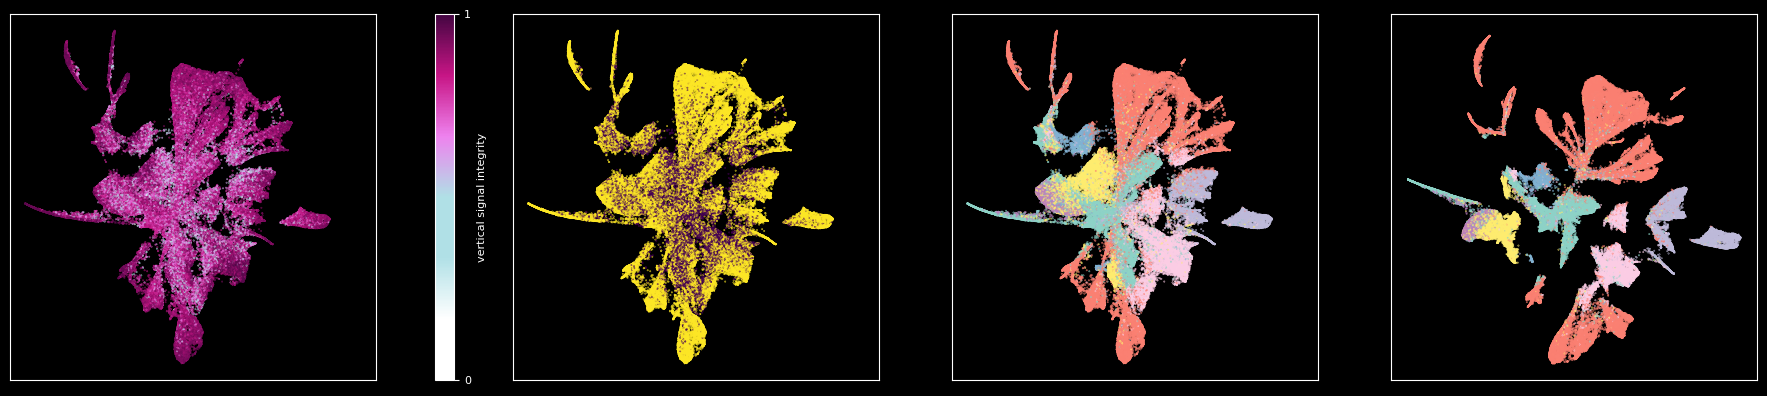

In [95]:
with plt.style.context("dark_background"):
    fig, axs = plt.subplots(ncols=5, figsize=(18, 4), width_ratios=[1, 0.05, 1, 1, 1])

    sc = axs[0].scatter(
        plot_df["x"],
        plot_df["y"],
        c=plot_df["mean_integrity"],
        cmap=BIH_CMAP,
        s=0.1,
        vmin=0,
        vmax=1,
    )
    fig.colorbar(
        sc, ax=axs[0], cax=axs[1], label="vertical signal integrity", ticks=[0, 1]
    )
    plot_df.plot.scatter(
        "x",
        "y",
        c=plot_df["mean_integrity"] > 0.7,
        cmap="viridis",
        s=0.1,
        ax=axs[2],
        colorbar=False,
    )

    plot_df.plot.scatter(
        "x", "y", c="class_short", cmap="Set3", s=0.1, ax=axs[3], colorbar=False
    )

    plot_clean_df.plot.scatter(
        "x", "y", c="class_short", cmap="Set3", s=0.1, ax=axs[4], colorbar=False
    )

    for i, ax in enumerate(axs.ravel()):
        if i == 1:
            continue
        ax.set_aspect("equal", adjustable="box")
        ax.set(xticks=[], yticks=[], xlabel=None, ylabel=None)
        ax.axis("square")

    fig.tight_layout()